# Penyeimbangan Data

Baik, saya jelaskan dalam bentuk narasi ya.

---

Penyeimbangan data adalah proses yang dilakukan ketika sebuah dataset memiliki distribusi kelas yang tidak merata, atau yang sering disebut sebagai *imbalanced data*. Pada kondisi ini, jumlah sampel dari kelas mayoritas jauh lebih besar dibandingkan dengan kelas minoritas. Masalah ini penting diperhatikan karena algoritma klasifikasi cenderung lebih “berpihak” pada kelas mayoritas. Akibatnya, meskipun akurasi keseluruhan terlihat tinggi, model sering gagal mengenali kelas minoritas. Hal ini bisa menjadi masalah serius terutama ketika kelas minoritas justru lebih penting, misalnya pada kasus deteksi penyakit atau fraud detection.

Dalam percobaan menggunakan data Iris, pada awalnya dataset memiliki distribusi yang seimbang, masing-masing kelas (Setosa, Versicolor, Virginica) terdiri dari 50 data. Namun, jika sebagian data dari salah satu kelas dihilangkan, maka dataset menjadi tidak seimbang. Misalnya, jumlah data Setosa tetap 50, sementara Versicolor hanya 50, dan Virginica hanya 15. Dalam kondisi seperti ini, ketika model dilatih, ia lebih sering menebak kelas Setosa karena jumlahnya dominan. Akibatnya, meskipun model mungkin masih mendapatkan akurasi yang cukup tinggi secara keseluruhan, performa pada kelas Versicolor dan Virginica menurun drastis, terutama pada metrik seperti recall dan f1-score.

Untuk mengatasi hal ini, dilakukan penyeimbangan data. Ada beberapa teknik yang bisa digunakan. Salah satunya adalah *undersampling*, yaitu mengurangi jumlah data dari kelas mayoritas agar sebanding dengan kelas minoritas. Cara lain adalah *oversampling*, yaitu menggandakan data dari kelas minoritas hingga jumlahnya sama dengan kelas mayoritas. Teknik yang lebih canggih adalah *SMOTE (Synthetic Minority Over-sampling Technique)*, yang tidak hanya menduplikasi data minoritas, tetapi juga menghasilkan data baru secara sintetis berdasarkan kedekatan antar data.

Setelah data diseimbangkan, distribusi antar kelas menjadi lebih merata, misalnya masing-masing kelas berisi 30 data. Model kemudian dilatih kembali pada data ini. Hasilnya, meskipun akurasi keseluruhan bisa saja sedikit menurun dibanding data yang tidak seimbang, performa model pada tiap kelas lebih konsisten. Model menjadi lebih adil dalam mengenali semua kelas, tidak hanya berfokus pada kelas mayoritas. Dengan kata lain, penyeimbangan data memberikan hasil yang lebih representatif dan meningkatkan kemampuan model dalam menangani variasi data di setiap kelas.


## Mengambil data set dari server

Pada tahap awal kita perlu mengambil dataset dari sumber dataset. Pada percobaan kali ini saya akan menggunakan data iris yang memiliki 150 record dengan 3 class dan saya akan menghapus class dari sentosa.

In [ ]:
!pip install pymysql
!pip install psycopg2-binary
!pip install pandas tabulate
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 42.1 MB/s eta 0:00:00


In [ ]:
import pymysql
import pandas as pd
from tabulate import tabulate

# Konfigurasi koneksi ke database MySQL
DB_HOST = "mysql-pendata23-175-mysqlpendata23-175.g.aivencloud.com"
DB_PORT = 17974
DB_NAME = "defaultdb"
DB_USER = "avnadmin"
DB_PASS = "AVNS_756YWhIqpe1WzSKsGNx"

try:
    # Membuat koneksi ke MySQL
    conn = pymysql.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASS,
        database=DB_NAME,
        cursorclass=pymysql.cursors.DictCursor  # Mengembalikan hasil sebagai dictionary
    )
    cur = conn.cursor()

    # Menjalankan query SQL
    query = "SELECT * FROM irisno.Iris ORDER BY id ASC;"  # Sesuaikan dengan nama tabel
    cur.execute(query)
    rows = cur.fetchall()

    # Jika tabel kosong
    if not rows:
        print("Tabel kosong, tidak ada data untuk ditampilkan.")
    else:
        # Mengubah hasil query menjadi DataFrame pandas
        df = pd.DataFrame(rows)

        # Menampilkan 3 data awal, titik-titik di tengah, dan 3 data akhir
        df_selected = pd.concat([df.head(3), pd.DataFrame([["..."] * len(df.columns)], columns=df.columns), df.tail(3)])

        # Menampilkan tabel dengan format psql
        print(tabulate(df_selected, headers="keys", tablefmt="psql", showindex=False))

except Exception as e:
    print("Error:", e)

finally:
    # Menutup koneksi ke database
    if cur:
        cur.close()
    if conn:
        conn.close()

+------+----------------+---------------+----------------+---------------+----------------+
| Id   | sepal length   | sepal width   | petal length   | petal width   | Class          |
|------+----------------+---------------+----------------+---------------+----------------|
| 1    | 5.1            | 3.5           | 1.4            | 0.2           | Iris-setosa    |
| 2    | 4.9            | 3.0           | 1.4            | 0.2           | Iris-setosa    |
| 3    | 4.7            | 3.2           | 1.3            | 0.2           | Iris-setosa    |
| ...  | ...            | ...           | ...            | ...           | ...            |
| 148  | 6.5            | 3.0           | 5.2            | 2.0           | Iris-virginica |
| 149  | 6.2            | 3.4           | 5.4            | 2.3           | Iris-virginica |
| 150  | 5.9            | 3.0           | 5.1            | 1.8           | Iris-virginica |
+------+----------------+---------------+----------------+---------------+------

## Melakukan penghapusan data

karena kita akan melakukan percobaan dengan data yang tidak seimbang tahap selanjutnya yaitu melakukan penghapusan data

In [ ]:
# Filter hanya class 'Setosa'
df_setosa = df[df['Class'] == 'Iris-setosa']

# Ambil hanya 15 record pertama dari Setosa
df_setosa_15 = df_setosa.head(15)

# Gabungkan dengan kelas lain (hapus sebagian besar Setosa, hanya sisakan 15 record)
df_balanced = pd.concat([df_setosa_15, df[df['Class'] != 'Iris-setosa']])

# Reset index biar rapi
df_balanced = df_balanced.reset_index(drop=True)

# Tampilkan hasil akhir
print(tabulate(df_balanced, headers="keys", tablefmt="psql", showindex=False))


+------+----------------+---------------+----------------+---------------+-----------------+
|   Id |   sepal length |   sepal width |   petal length |   petal width | Class           |
|------+----------------+---------------+----------------+---------------+-----------------|
|    1 |            5.1 |           3.5 |            1.4 |           0.2 | Iris-setosa     |
|    2 |            4.9 |           3   |            1.4 |           0.2 | Iris-setosa     |
|    3 |            4.7 |           3.2 |            1.3 |           0.2 | Iris-setosa     |
|    4 |            4.6 |           3.1 |            1.5 |           0.2 | Iris-setosa     |
|    5 |            5   |           3.6 |            1.4 |           0.2 | Iris-setosa     |
|    6 |            5.4 |           3.9 |            1.7 |           0.4 | Iris-setosa     |
|    7 |            4.6 |           3.4 |            1.4 |           0.3 | Iris-setosa     |
|    8 |            5   |           3.4 |            1.5 |           0

## Visualisasi data dengan Menggunakan PCA

karena pada data iris mempunyai 4 fitur yang akan dihitung jaraknya nantinya dan kita akan mevisualiasasikan dalam 2 dimensi maka kita menggunakan PCA.

### 📘 Apa itu PCA (Principal Component Analysis)?

**PCA** atau *Principal Component Analysis* adalah **metode reduksi dimensi** yang digunakan dalam *machine learning* dan *data analysis* untuk menyederhanakan data berdimensi tinggi tanpa kehilangan informasi penting secara signifikan.

---

### 🎯 Tujuan PCA:

* **Mengurangi dimensi data** (fitur) menjadi lebih sedikit agar:

  * Analisis menjadi lebih mudah dan cepat.
  * Visualisasi data (misalnya ke 2D atau 3D) menjadi mungkin.
* **Menghilangkan redundansi** (fitur yang saling berkorelasi).
* **Menangkap variansi terbesar** dalam data dengan jumlah komponen yang lebih sedikit.

---

### 🛠️ Cara Kerja PCA (Secara Ringkas):

Berikut adalah rumus utama dalam **Principal Component Analysis (PCA)**

---

### 1. **Standarisasi Data**

Setiap fitur $x_j$ dari data distandarisasi:

$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

* $x_{ij}$: nilai fitur ke-$j$ dari data ke-$i$
* $\mu_j$: rata-rata fitur ke-$j$
* $\sigma_j$: standar deviasi fitur ke-$j$

---

### 2. **Kovarian Matriks**

Hitung matriks kovarian $\mathbf{C}$ dari data yang telah distandarisasi:

$$
\mathbf{C} = \frac{1}{n-1} \mathbf{Z}^\top \mathbf{Z}
$$

* $\mathbf{Z}$: matriks data hasil standarisasi
* $n$: jumlah sampel

---

### 3. **Eigenvalue dan Eigenvector**

Cari **eigenvalue** dan **eigenvector** dari matriks kovarian:

$$
\mathbf{C} \mathbf{v} = \lambda \mathbf{v}
$$

* $\lambda$: eigenvalue (mengukur variansi)
* $\mathbf{v}$: eigenvector (arah komponen utama)

---

### 4. **Proyeksi ke Komponen Utama**

Proyeksikan data ke komponen utama:

$$
\mathbf{Z}_{\text{baru}} = \mathbf{Z} \mathbf{W}
$$

* $\mathbf{W}$: matriks yang terdiri dari $k$ eigenvector utama
* $\mathbf{Z}_{\text{baru}}$: data dalam ruang berdimensi lebih rendah (misalnya 2D)

### 📐 Contoh:

Jika Anda memiliki data dengan 4 fitur seperti:

* Petal length
* Petal width
* Sepal length
* Sepal width

...dengan PCA, Anda bisa mereduksinya ke 2 dimensi (komponen utama) seperti:

* PC1 (principal component 1)
* PC2 (principal component 2)

Lalu Anda bisa mem-**plot** data tersebut secara visual untuk melihat struktur klasternya lebih jelas.




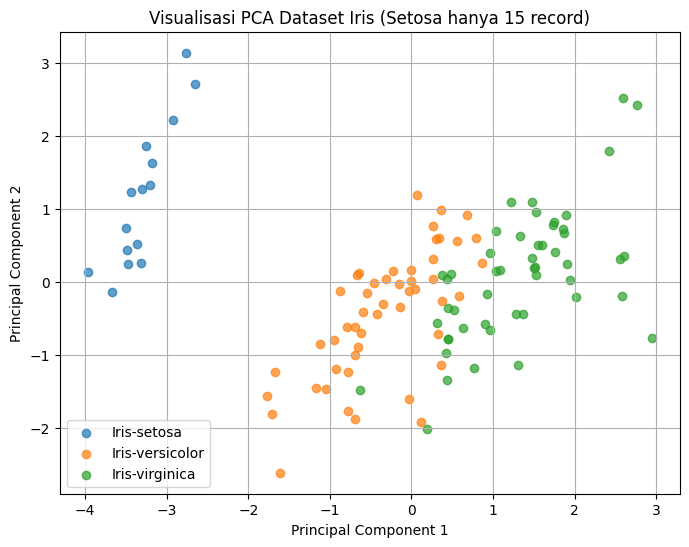

In [ ]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Ambil fitur numerik ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Normalisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Lakukan PCA (2 komponen utama) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Buat DataFrame baru hasil PCA ---
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y.values

# --- Visualisasi scatter plot PCA ---
plt.figure(figsize=(8,6))
for kelas in df_pca['Class'].unique():
    subset = df_pca[df_pca['Class'] == kelas]
    plt.scatter(subset['PC1'], subset['PC2'], label=kelas, alpha=0.7)

plt.title("Visualisasi PCA Dataset Iris (Setosa hanya 15 record)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


## Melakukan Klasifikasi dengan Menggunakan KNN

**K-Nearest Neighbors (KNN)** adalah algoritma **klasifikasi berbasis instance-based learning**, di mana suatu data baru diklasifikasikan berdasarkan kedekatannya dengan data-data yang sudah memiliki label kelas.

Berbeda dengan **K-Means** yang bersifat **unsupervised** (tanpa label), **KNN membutuhkan data berlabel** untuk melatih model.

### Langkah-Langkah Algoritma KNN

1. **Tentukan jumlah tetangga terdekat ($k$)**
   Misalnya, kita gunakan $k=3$. Artinya, sebuah data baru akan dilihat kelasnya berdasarkan 3 tetangga terdekat.

2. **Hitung jarak antara data uji dengan seluruh data latih**
   Jarak yang paling sering digunakan adalah **Euclidean Distance**:

   $$
   d(\mathbf{x}, \mathbf{y}) = \sqrt{ \sum_{i=1}^{n} (x_i - y_i)^2 }
   $$

   * $\mathbf{x}, \mathbf{y}$: dua titik data
   * $n$: jumlah fitur (contoh pada Iris ada 4 fitur: sepal length, sepal width, petal length, petal width)

3. **Ambil $k$ tetangga terdekat**
   Urutkan jarak terkecil, lalu ambil $k$ data dengan jarak terdekat.

4. **Voting mayoritas**
   Dari $k$ tetangga tersebut, lihat kelasnya.

   * Jika mayoritas dari tetangga berlabel "Setosa", maka data baru diklasifikasikan sebagai "Setosa".

5. **Prediksi kelas data uji**
   Hasil akhir adalah label mayoritas dari tetangga terdekat tersebut.

---

### ✅ Penjelasan Inti

* **KNN menggunakan label data** → berbeda dengan K-Means yang tidak punya label.
* **Parameter utama adalah $k$** → terlalu kecil bisa menyebabkan noise, terlalu besar bisa membuat hasil tidak spesifik.
* **KNN cocok untuk klasifikasi data sederhana** seperti dataset **Iris** yang memiliki 3 kelas (`Setosa`, `Versicolor`, `Virginica`).

---

Mau saya bikinkan juga **contoh perhitungan manual KNN (misalnya 1 titik uji terhadap 3 tetangga terdekat)** supaya lebih jelas sebelum masuk ke kode Python?


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Encode label (ubah Setosa/Versicolor/Virginica -> angka 0,1,2) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# --- Buat model KNN dengan k=3 ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# --- Prediksi ---
y_pred = knn.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi KNN (k=3): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[ 5  0  0]
 [ 0 14  1]
 [ 0  1 14]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.94        35
      macro avg       0.96      0.96      0.96        35
   weighted avg       0.94      0.94      0.94        35


Akurasi KNN (k=3): 0.9429


## Melakukan Preprocessing dengan Menyeimbangkan Data Menggunakan SMOTE

Dalam klasifikasi, sering kali kita menghadapi masalah **ketidakseimbangan data** (*imbalanced dataset*). Misalnya, pada data Iris yang sudah dimodifikasi, jumlah record untuk kelas **Setosa** hanya 15, sedangkan dua kelas lainnya (Versicolor dan Virginica) masing-masing berjumlah 50. Kondisi seperti ini membuat model cenderung **bias** terhadap kelas mayoritas, sehingga akurasinya tampak tinggi tetapi kemampuan dalam mengenali kelas minoritas sangat rendah.

Untuk mengatasi hal ini, digunakan teknik **oversampling**, salah satunya adalah **SMOTE (Synthetic Minority Oversampling Technique)**.

---

### 🔎 Bagaimana SMOTE Bekerja?

1. **Identifikasi kelas minoritas**
   Algoritma mendeteksi kelas yang jumlah datanya lebih sedikit dibanding kelas mayoritas.

2. **Pemilihan tetangga terdekat (k-nearest neighbors)**
   Untuk setiap sampel di kelas minoritas, SMOTE mencari sejumlah tetangga terdekat (misalnya *k = 5*).

3. **Interpolasi untuk membuat data sintetis**
   Data baru dibuat di sepanjang garis yang menghubungkan sampel minoritas dengan tetangganya. Rumus:

   $$
   x_{new} = x_i + \delta \cdot (x_{zi} - x_i)
   $$

   * \$x\_i\$: data minoritas asli
   * \$x\_{zi}\$: salah satu tetangga terdekat dari \$x\_i\$
   * \$\delta\$: bilangan acak antara 0 dan 1
   * \$x\_{new}\$: data sintetis hasil SMOTE

   Dengan kata lain, titik baru bukan duplikasi, melainkan titik hasil interpolasi yang berada di antara data minoritas yang ada dengan tetangganya.

4. **Gabungkan data asli dengan data sintetis**
   Setelah proses ini, distribusi kelas menjadi **lebih seimbang**.

---

### ✅ Kelebihan SMOTE

* Menghasilkan **data sintetis yang lebih realistis** dibanding oversampling dengan duplikasi.
* Membantu classifier lebih baik dalam mengenali kelas minoritas.
* Mengurangi bias model terhadap kelas mayoritas.

---

### 🌸 Contoh pada Dataset Iris

* **Sebelum penyeimbangan**:

  * Setosa: 15
  * Versicolor: 50
  * Virginica: 50

* **Sesudah SMOTE**:

  * Setosa ditambah dengan data sintetis sehingga jumlahnya mendekati kelas lain.
  * Versicolor & Virginica tetap sama.

Dengan demikian, dataset menjadi **seimbang**, dan hasil klasifikasi (misalnya dengan KNN atau Decision Tree) akan lebih adil dalam mengenali semua kelas.



In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# --- Ambil dataset Iris ---
iris = load_iris()
X = iris.data
y = iris.target

# Buat data tidak seimbang: kurangi class 0 jadi cuma 15 data
X_imbalanced = X[y != 0]      # ambil class 1 & 2 penuh
y_imbalanced = y[y != 0]

# tambahkan sebagian kecil class 0 (15 data saja)
X_imbalanced = pd.concat([pd.DataFrame(X_imbalanced), pd.DataFrame(X[y == 0][:15])])
y_imbalanced = pd.concat([pd.Series(y_imbalanced), pd.Series(y[y == 0][:15])])

print("Distribusi sebelum SMOTE:", Counter(y_imbalanced))

# --- Standarisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imbalanced)

# --- Terapkan SMOTE ---
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_imbalanced)

print("Distribusi sesudah SMOTE:", Counter(y_resampled))


Distribusi sebelum SMOTE: Counter({1: 50, 2: 50, 0: 15})
Distribusi sesudah SMOTE: Counter({1: 50, 2: 50, 0: 50})


In [ ]:

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Ambil fitur numerik ---
X = df_balanced[['sepal length', 'sepal width', 'petal length', 'petal width']]
y = df_balanced['Class']

# --- Normalisasi data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Lakukan PCA (2 komponen utama) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Buat DataFrame baru hasil PCA ---
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Class'] = y.values

# --- Visualisasi scatter plot PCA ---
plt.figure(figsize=(8,6))
for kelas in df_pca['Class'].unique():
    subset = df_pca[df_pca['Class'] == kelas]
    plt.scatter(subset['PC1'], subset['PC2'], label=kelas, alpha=0.7)

plt.title("Visualisasi PCA Dataset Iris (Setosa hanya 15 record)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()


## Visualisasi data seimbang dengan PCA

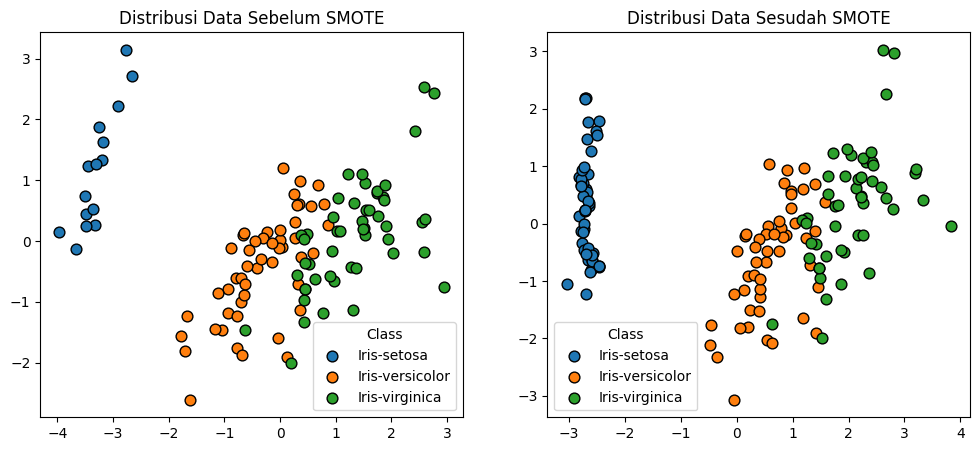

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- PCA sebelum SMOTE ---
pca = PCA(n_components=2)
X_pca_before = pca.fit_transform(X_scaled)

# --- PCA sesudah SMOTE ---
X_pca_after = pca.fit_transform(X_resampled)

# --- Mapping angka ke nama kelas ---
class_names = label_encoder.inverse_transform(sorted(set(y_encoded)))

# --- Plot hasil ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot sebelum SMOTE
for class_idx, class_name in enumerate(class_names):
    mask = (y_imbalanced == class_idx)
    ax[0].scatter(X_pca_before[mask, 0], X_pca_before[mask, 1],
                  label=class_name, edgecolor='k', s=60)
ax[0].set_title("Distribusi Data Sebelum SMOTE")
ax[0].legend(title="Class")

# Plot sesudah SMOTE
for class_idx, class_name in enumerate(class_names):
    mask = (y_resampled == class_idx)
    ax[1].scatter(X_pca_after[mask, 0], X_pca_after[mask, 1],
                  label=class_name, edgecolor='k', s=60)
ax[1].set_title("Distribusi Data Sesudah SMOTE")
ax[1].legend(title="Class")

plt.show()


## Klasifikasi dengan menggunakan KNN pada data yang sudah imbang

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Ambil fitur dan label dari hasil SMOTE ---
X = X_resampled
y = y_resampled

# --- Decode label ke nama kelas (0,1,2 -> Setosa, Versicolor, Virginica) ---
# (Jika sebelumnya sudah ada label_encoder, kita bisa pakai lagi)
# Jika belum, buat encoder baru
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)   # <- tidak perlu, karena sudah encoded

# --- Normalisasi fitur ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Split data (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# --- Buat model KNN dengan k=3 ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# --- Prediksi ---
y_pred = knn.predict(X_test)

# --- Evaluasi ---
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print(f"\nAkurasi KNN (k=3): {accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.79      1.00      0.88        15
 Iris-virginica       1.00      0.73      0.85        15

       accuracy                           0.91        45
      macro avg       0.93      0.91      0.91        45
   weighted avg       0.93      0.91      0.91        45


Akurasi KNN (k=3): 0.9111


## Kesimpulan


### 🔹 1. **Klasifikasi setelah menghapus Iris-setosa dari data latih**

* **Confusion Matrix** menunjukkan prediksi yang sangat baik:

  * Iris-setosa diprediksi sempurna (5/5 benar).
  * Iris-versicolor dan Iris-virginica hanya mengalami sedikit kesalahan (1 salah pada masing-masing kelas).
* **Classification Report**:

  * Precision, Recall, dan F1-score rata-rata ≈ **0.93 – 1.00**.
  * Akurasi keseluruhan **94.29%**.
* **Kesimpulan**:
  Walaupun model **tidak pernah dilatih dengan data Iris-setosa**, model KNN tetap mampu mengenali Setosa dengan benar ketika diuji pada data penuh. Hal ini karena **Setosa memiliki ciri morfologi yang sangat berbeda** (misalnya petal lebih pendek), sehingga mudah dibedakan dari dua kelas lainnya.



### 🔹 2. **Klasifikasi dengan data latih diseimbangkan menggunakan SMOTE**

* **Confusion Matrix**:

  * Iris-setosa diprediksi sempurna (15/15 benar).
  * Iris-versicolor diprediksi benar semua (15/15 benar).
  * Iris-virginica mengalami lebih banyak salah klasifikasi (4 salah ke Versicolor).
* **Classification Report**:

  * Precision dan Recall masih cukup tinggi, tetapi Virginica **recall turun ke 0.73**.
  * Akurasi keseluruhan **91.11%**.
* **Kesimpulan**:
  Dengan SMOTE, data latih menjadi seimbang, sehingga model tidak bias pada kelas mayoritas. Namun, akibat penambahan sampel sintetis, **Virginica cenderung sulit dibedakan dari Versicolor** (karena keduanya memang mirip secara fitur). Akibatnya, performa Virginica menurun meskipun Setosa dan Versicolor sangat baik.



### 🔎 **Perbandingan Utama**

| Metode                    | Akurasi    | Kelebihan                                              | Kekurangan                                     |
| ------------------------- | ---------- | ------------------------------------------------------ | ---------------------------------------------- |
| **Tanpa Setosa di latih** | **94.29%** | Model tetap bisa mendeteksi Setosa karena cirinya unik | Risiko bias kalau kelas lain mirip             |
| **Dengan SMOTE**          | **91.11%** | Data lebih seimbang, tidak bias ke kelas tertentu      | Virginica jadi sulit dibedakan dari Versicolor |


👉 **Kesimpulan akhir**:

* Menghapus Setosa dari data latih **tidak menurunkan akurasi secara signifikan** karena Setosa mudah dibedakan.
* SMOTE membantu menyeimbangkan data, tetapi justru memperumit klasifikasi **Virginica vs Versicolor**, sehingga akurasi sedikit turun.
* Untuk dataset seperti Iris yang relatif seimbang, **SMOTE tidak selalu lebih baik**, kecuali pada dataset dengan **ketidakseimbangan kelas yang ekstrem**.


